<a href="https://colab.research.google.com/github/niveditatrinaya/eurosat-satellite-classifier/blob/main/eurosat_satellite_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install kaggle

In [3]:
import os, json
from getpass import getpass

username = input("Enter your Kaggle username: ")
key = getpass("Paste your Kaggle API token: ")

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": username, "key": key}, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle credentials saved.")

Enter your Kaggle username: nivatarakavya
Paste your Kaggle API token: ··········
Kaggle credentials saved.


In [4]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:58<00:00, 37.3MB/s]



In [5]:
!unzip -q -o eurosat-dataset.zip -d EuroSAT_data

In [6]:
!ls EuroSAT_data/EuroSAT

AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
import torch
from torchvision import datasets
from torch.utils.data import random_split, Subset

full_dataset = datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_dataset), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_set = Subset(full_dataset, train_indices)
val_set = Subset(datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=test_transform), val_indices)
test_set = Subset(datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=test_transform), test_indices)

print(f"Train size: {len(train_set)}, Val size: {len(val_set)}, Test size: {len(test_set)}")

Train size: 21600, Val size: 2700, Test size: 2700


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [10]:
import torch.nn as nn
from torchvision import models

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(2048, 10)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


Linear(in_features=2048, out_features=10, bias=True)


In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [12]:
scaler = torch.amp.GradScaler('cuda')

epochs = 10

for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Train Loss: 0.6119, Train Acc: 83.02% | Val Loss: 0.3343, Val Acc: 90.37%
Epoch 2/10 | Train Loss: 0.3290, Train Acc: 89.69% | Val Loss: 0.2529, Val Acc: 92.15%
Epoch 3/10 | Train Loss: 0.2744, Train Acc: 91.19% | Val Loss: 0.2264, Val Acc: 93.04%
Epoch 4/10 | Train Loss: 0.2489, Train Acc: 92.08% | Val Loss: 0.2000, Val Acc: 93.85%
Epoch 5/10 | Train Loss: 0.2319, Train Acc: 92.41% | Val Loss: 0.1921, Val Acc: 93.59%
Epoch 6/10 | Train Loss: 0.2139, Train Acc: 92.85% | Val Loss: 0.1886, Val Acc: 94.15%
Epoch 7/10 | Train Loss: 0.2044, Train Acc: 93.23% | Val Loss: 0.1934, Val Acc: 93.56%
Epoch 8/10 | Train Loss: 0.2000, Train Acc: 93.27% | Val Loss: 0.1728, Val Acc: 94.15%
Epoch 9/10 | Train Loss: 0.1960, Train Acc: 93.33% | Val Loss: 0.1683, Val Acc: 94.44%
Epoch 10/10 | Train Loss: 0.1838, Train Acc: 93.99% | Val Loss: 0.1711, Val Acc: 94.33%


In [13]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# New optimizer with a smaller learning rate, covering ALL parameters now
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [14]:
best_val_acc = 0.0

epochs = 5

for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # --- Checkpointing ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best model saved (Val Acc: {val_acc:.2f}%)")

Epoch 1/5 | Train Loss: 0.1275, Train Acc: 95.67% | Val Loss: 0.0779, Val Acc: 97.48%
  -> New best model saved (Val Acc: 97.48%)
Epoch 2/5 | Train Loss: 0.0754, Train Acc: 97.47% | Val Loss: 0.0755, Val Acc: 97.89%
  -> New best model saved (Val Acc: 97.89%)
Epoch 3/5 | Train Loss: 0.0504, Train Acc: 98.21% | Val Loss: 0.0633, Val Acc: 97.93%
  -> New best model saved (Val Acc: 97.93%)
Epoch 4/5 | Train Loss: 0.0429, Train Acc: 98.56% | Val Loss: 0.0655, Val Acc: 98.30%
  -> New best model saved (Val Acc: 98.30%)
Epoch 5/5 | Train Loss: 0.0359, Train Acc: 98.74% | Val Loss: 0.0609, Val Acc: 98.37%
  -> New best model saved (Val Acc: 98.37%)


In [15]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = full_dataset.classes

print(classification_report(all_labels, all_preds, target_names=class_names))

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.99      0.98       300
              Forest       1.00      0.99      0.99       297
HerbaceousVegetation       0.98      0.98      0.98       302
             Highway       0.97      0.97      0.97       269
          Industrial       0.98      0.98      0.98       257
             Pasture       0.96      0.97      0.97       187
       PermanentCrop       1.00      0.98      0.99       254
         Residential       0.98      0.99      0.99       314
               River       0.98      0.97      0.98       245
             SeaLake       0.99      1.00      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



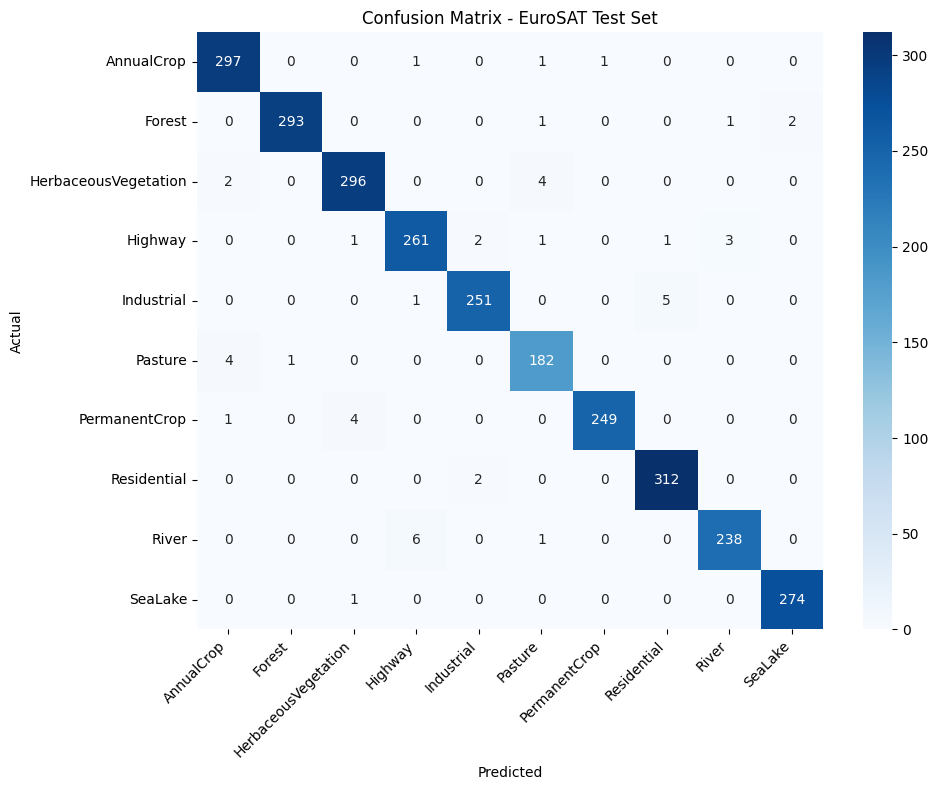

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - EuroSAT Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()